### Install necessary libraries

In [12]:
!pip install --upgrade --quiet langchain-google-genai

In [13]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI


# Initialize the model
gemini_client = ChatGoogleGenerativeAI(model="gemini-2.5-flash", api_key=userdata.get("NEW_1"))

# Now you can use the llm to interact with the model
# notice the similarity with sklearn's model.predict
response = gemini_client.invoke("""

### ROLE

You are a **world-class educator, instructional designer, and subject-matter expert** with the ability to explain complex topics in a clear, engaging, and structured way. You specialize in breaking down difficult concepts so beginners can understand them quickly while still providing depth for deeper learning.

### CONTEXT

The user will provide a **specific topic later**. Your responsibility is to design a **complete learning explanation and mini-lesson** that teaches the topic effectively. The audience is assumed to be **curious learners with little to moderate prior knowledge**.

Your explanation should focus on **clarity, engagement, and practical understanding**, not just theoretical definitions.

### TASK

When the user provides a topic, complete the following steps:

1. **Introduce the Topic**

   * Provide a simple, beginner-friendly overview.
   * Explain why the topic is important or useful.

2. **Explain the Core Concept**

   * Break the topic into **clear sections or sub-concepts**.
   * Use simple language and logical progression.

3. **Use Analogies or Real-World Examples**

   * Provide relatable examples to make the idea easier to understand.

4. **Step-by-Step Breakdown (if applicable)**

   * Explain processes or mechanisms clearly in steps.

5. **Common Mistakes or Misconceptions**

   * Identify misunderstandings learners often have.

6. **Practical Application**

   * Explain how the concept is used in real life, work, or technology.

7. **Quick Summary**

   * Provide a concise recap of the key points.

8. **Optional Challenge or Practice Question**

   * Add one short exercise or reflection question to reinforce learning.

### CONSTRAINTS

* Use **clear, simple language** suitable for beginners.
* Avoid unnecessary jargon; explain technical terms if used.
* Keep explanations **structured and easy to scan**.
* Do not assume advanced prior knowledge.
* Focus on **teaching, not just defining**.
* Avoid overly long paragraphs.

### EXAMPLES

**Input Topic:**
"Photosynthesis"

**Output Style Example (short sample):**

**Introduction:**
Photosynthesis is the process plants use to turn sunlight into energy. It allows plants to create food from sunlight, water, and carbon dioxide.

**Simple Analogy:**
Think of a plant as a tiny solar-powered food factory.

**Key Steps:**

1. Plants capture sunlight using chlorophyll.
2. They absorb water from the soil.
3. They take in carbon dioxide from the air.
4. These ingredients are converted into glucose (food) and oxygen.

**Real-World Importance:**
Photosynthesis produces the oxygen we breathe and forms the base of the food chain.

### OUTPUT FORMAT

Structure the response using the following format:

```
# Topic: [Topic Name]

## 1. Simple Introduction
[Explanation]

## 2. Core Concepts
- Concept 1
- Concept 2
- Concept 3

## 3. Analogy or Real-World Example

## 4. Step-by-Step Explanation (if applicable)

## 5. Common Misconceptions

## 6. Real-World Applications

## 7. Quick Summary (3–5 bullet points)

## 8. Practice Question
```
TOPIC IS BAYESIAN THEOREM.

""")
print(response.content)

# Topic: Bayesian Theorem

## 1. Simple Introduction
Imagine you have an initial belief about something, and then you get some new information or evidence. How do you update your belief in a logical, mathematical way? That's exactly what **Bayesian Theorem** helps us do!

At its heart, Bayesian Theorem is a powerful rule in probability that shows how to update the probability of an event happening based on new evidence. It’s not just about predicting the future, but about refining our understanding of the present or past by incorporating new data. It helps us answer questions like: "Given this new piece of information, how likely is my original guess to be true now?"

**Why is it important?** Because in real life, we rarely have perfect information. We start with some assumptions or prior knowledge, and as we gather more data, we need a systematic way to adjust our thinking. Bayesian Theorem provides that framework, making it incredibly useful in fields ranging from science and medicin

# Let's talk about RAG, now

# Our Approach

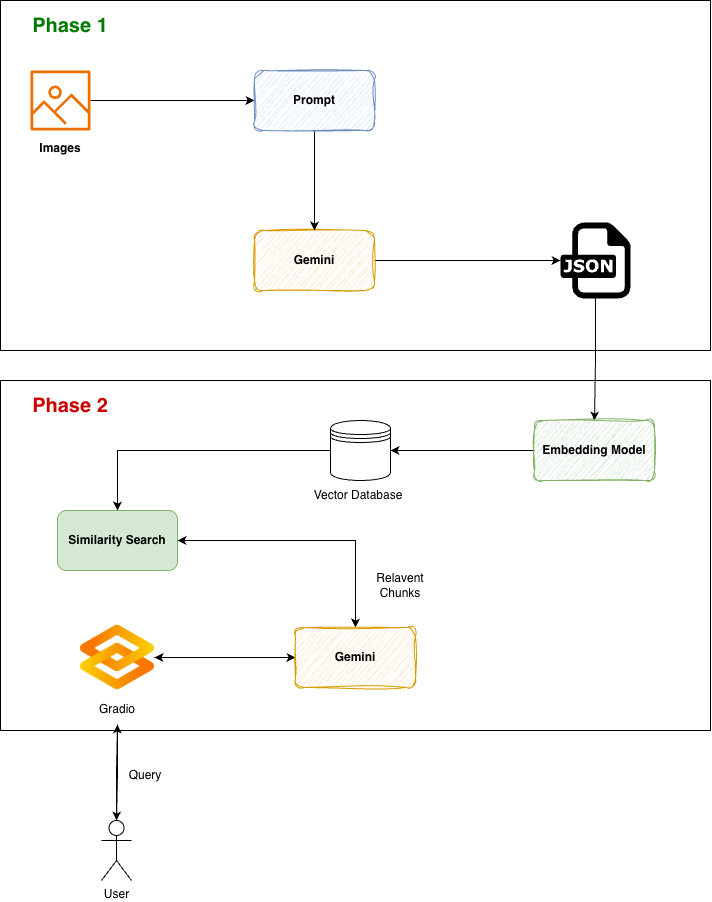

## The prompt

In [14]:
image_description_prompt = """
**Role:**
You are an expert Computer Vision Metadata Specialist and SEO Archivist. You possess a deep understanding of visual semantics, image indexing, and natural language retrieval. Your capability involves translating visual data into precise, machine-readable text optimized for search algorithms.

**Context:**
We are building a high-performance multimodal search engine. The metadata you generate will be used to populate a vector database, allowing users to find images using both specific keyword matching and semantic natural language queries (e.g., "a quiet place to work with coffee"). High accuracy and descriptive depth are required to distinguish between similar images.

**Task:**
Analyze the provided image and generate a structured JSON object containing detailed metadata. You must extract the main subject, describe the scene atmospherics, identify visual elements, transcribe specific text, and generate search-optimized keywords.

**Constraints:**

1.  **Description:** Must be objective and factual. Limit to 2-3 sentences. Focus on action, lighting, and mood.
2.  **Text Content:** If no text is visible, return `null`. If text is visible, transcribe it exactly as it appears, preserving case where possible.
3.  **Keywords:** Provide exactly 10-15 keywords. Mix broad concepts (e.g., "urban," "melancholy") with specific objects (e.g., "red umbrella," "taxi").
4.  **Safety:** Do not generate content that violates safety policies. If the image is unclear or blurry, note this in the description.
5.  **Format:** The output must be raw JSON only. Do not include markdown formatting (like ` json ...  `) or conversational filler.

**Examples:**

*Input:* [An image of a golden retriever catching a frisbee in a park on a sunny day]

*Output:*

```json
{
  "main_subject": "Golden Retriever dog",
  "detailed_description": "A golden retriever leaps into the air to catch a red frisbee against a clear blue sky. The lighting is bright and natural, casting sharp shadows on the green grass below. The mood is energetic and playful.",
  "visual_elements": [
    "Golden Retriever",
    "Red Frisbee",
    "Green Grass",
    "Blue Sky",
    "Motion Blur"
  ],
  "text_content": null,
  "search_keywords": [
    "dog",
    "pet",
    "playing",
    "fetch",
    "frisbee",
    "park",
    "sunny",
    "action shot",
    "canine",
    "jumping",
    "outdoor",
    "joyful",
    "golden retriever",
    "summer"
  ]
}
```

**Output Format:**
Generate the response in the following JSON structure:

```json
{
  "main_subject": "String",
  "detailed_description": "String",
  "visual_elements": ["String", "String"],
  "text_content": "String or null",
  "search_keywords": ["String", "String"]
}
```
"""

# Processing One Image

In [15]:
import os
import base64
import mimetypes
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# 1. Setup
os.environ["GOOGLE_API_KEY"] = userdata.get("NEW_1")

# Initialize the model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

# 2. Helper function to encode image to Base64
def encode_image(image_path):
    """Encodes a local image to base64 string."""
    # https://en.wikipedia.org/wiki/Base64
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# 3. The Metadata Function
def generate_search_metadata(image_path, llm, prompt_text):
    """
    Generates a detailed description using LangChain and Gemini.
    """
    try:
        # Determine mime type (e.g., 'image/jpeg', 'image/png')
        mime_type, _ = mimetypes.guess_type(image_path)
        if not mime_type:
            mime_type = 'image/jpeg' # Default fallback

        # Get Base64 string
        img_base64 = encode_image(image_path)

        # Create the Multimodal Message
        # LangChain expects a list of dictionaries for multimodal content
        message = HumanMessage(
            content=[
                {"type": "text", "text": prompt_text},
                {"type": "image_url", "image_url": {"url": f"data:{mime_type};base64,{img_base64}"}}
            ]
        )

        # Invoke the LLM
        response = llm.invoke([message])

        return response.content.replace('```json', '').replace('```', '')

    except FileNotFoundError:
        print(f"Error: The file at {image_path} was not found.")
        return None
    except Exception as e:
        print(f"An error occurred during generation: {e}")
        return None

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
image_path = "/content/drive/MyDrive/21 day assignments/GenAI/Images/Cat.avif"

# Run the function
metadata = generate_search_metadata(image_path, llm, image_description_prompt)

if metadata:
    print(metadata)


{
  "main_subject": "Grey tabby cat",
  "detailed_description": "A grey tabby cat with large, round amber eyes sits attentively on a polished wooden floor, looking directly at the viewer. It wears a two-toned orange and yellow collar. The lighting is soft and even, highlighting its striped fur against a plain, light-colored wall, creating a curious and calm mood.",
  "visual_elements": [
    "Grey cat",
    "Tabby markings",
    "Amber eyes",
    "Orange collar",
    "Yellow collar",
    "Whiskers",
    "Wooden floor",
    "Light-colored wall",
    "Cat's tail"
  ],
  "text_content": null,
  "search_keywords": [
    "cat",
    "kitten",
    "pet",
    "grey cat",
    "tabby cat",
    "British Shorthair",
    "domestic cat",
    "animal",
    "cute",
    "curious",
    "alert",
    "orange collar",
    "yellow collar",
    "wooden floor",
    "indoor"
  ]
}



# Processing All Images

In [18]:
import os
import json

source_folder = "/content/drive/MyDrive/21 day assignments/GenAI/Images"
output_folder = "/content/drive/MyDrive/21 day assignments/GenAI/jsons"

os.makedirs(output_folder, exist_ok=True)

# Supported image extensions to filter for
valid_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.heic')

print(f"Starting processing for images in: {source_folder}\n")

files = os.listdir(source_folder)
# Calculate total relevant files for the progress counter
total_files = len([f for f in files if f.lower().endswith(valid_extensions)])
processed_count = 0

for filename in files:
    if filename.lower().endswith(valid_extensions):

        image_path = os.path.join(source_folder, filename)

        # Define the output JSON path (same name as image, but .json extension)
        json_filename = f"{os.path.splitext(filename)[0]}.json"
        json_path = os.path.join(output_folder, json_filename)

        if os.path.exists(json_path):
            print(f"[{processed_count + 1}/{total_files}] Skipping: {filename} (JSON already exists)")
            processed_count += 1
            continue

        print(f"[{processed_count + 1}/{total_files}] Generating metadata for: {filename}...")

        try:
            # Call your existing function
            description = generate_search_metadata(image_path, llm, image_description_prompt)

            # Ensure description is parsed to dict if returned as string
            if isinstance(description, str):
                description = json.loads(description)

            if description:
                # Prepare the data structure
                data = {
                    "file_path": image_path,
                    "description": description
                }

                # Write to JSON file
                with open(json_path, 'w', encoding='utf-8') as json_file:
                    json.dump(data, json_file, indent=4)

                print(f"   -> Saved to {json_filename}")
            else:
                print(f"   -> Skipped {filename} (Generation returned empty)")

        except Exception as e:
            print(f"   -> Error processing {filename}: {e}")

        processed_count += 1

print("\n--- Processing Complete ---")

Starting processing for images in: /content/drive/MyDrive/21 day assignments/GenAI/Images

[1/7] Skipping: Golden-Retriever.webp (JSON already exists)
[2/7] Skipping: tiger.jpeg (JSON already exists)
[3/7] Skipping: panda.jpg (JSON already exists)
[4/7] Skipping: kangaroo.jpg (JSON already exists)
[5/7] Skipping: elephant-2870777_1280.jpg (JSON already exists)
[6/7] Skipping: animals_hero_penguin_02_1.jpg (JSON already exists)
[7/7] Skipping: rhino.jpg (JSON already exists)

--- Processing Complete ---


# Creating Embeddings

In [25]:
!pip install -U -q langchain-google-genai langchain-chroma chromadb
!pip install -q google-genai

In [27]:
# RUN THIS FIRST to see what embedding models your key can access
from google import genai
from google.colab import userdata

API_KEY = userdata.get("NEW_1")
client = genai.Client(api_key=API_KEY)

for m in client.models.list():
    if "embed" in m.name.lower():
        print(m.name)

models/gemini-embedding-001
models/gemini-embedding-2-preview


In [32]:
import os, json, time, shutil, requests
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings
from google.colab import userdata

API_KEY = userdata.get("NEW_1")
os.environ["GOOGLE_API_KEY"] = API_KEY

json_folder  = "/content/drive/MyDrive/21 day assignments/GenAI/jsons/"
db_path_local = "/content/chroma_db"          # ← local disk, writable
db_path_drive = "/content/drive/MyDrive/21 day assignments/GenAI/chroma_db"  # ← final save location

class GeminiEmbeddings(Embeddings):
    def __init__(self, api_key, model="gemini-embedding-001"):
        self.api_key = api_key
        self.url = (
            f"https://generativelanguage.googleapis.com/v1beta/models/"
            f"{model}:embedContent?key={api_key}"
        )
        self.model_path = f"models/{model}"

    def _embed(self, text, task_type):
        body = {
            "model": self.model_path,
            "content": {"parts": [{"text": text}]},
            "taskType": task_type
        }
        r = requests.post(self.url, json=body)
        r.raise_for_status()
        return r.json()["embedding"]["values"]

    def embed_documents(self, texts):
        return [self._embed(t, "RETRIEVAL_DOCUMENT") for t in texts]

    def embed_query(self, text):
        return self._embed(text, "RETRIEVAL_QUERY")

embeddings = GeminiEmbeddings(API_KEY)

# Clean local DB
if os.path.exists(db_path_local):
    shutil.rmtree(db_path_local)
    print("Cleaned local DB.")

# Load JSON files
documents = []
if os.path.exists(json_folder):
    files = [f for f in os.listdir(json_folder) if f.endswith('.json')]
    print(f"Found {len(files)} JSON files. Preparing data...")
    for filename in files:
        with open(os.path.join(json_folder, filename), 'r', encoding='utf-8') as f:
            data = json.load(f)
            desc_obj = data.get("description", {})
            text_content = (
                f"Subject: {desc_obj.get('main_subject', 'Unknown')}\n"
                f"Description: {desc_obj.get('detailed_description', '')}\n"
                f"Keywords: {', '.join(desc_obj.get('search_keywords', []))}\n"
                f"Visual Elements: {', '.join(desc_obj.get('visual_elements', []))}"
            )
            documents.append(Document(
                page_content=text_content,
                metadata={"file_name": filename,
                          "file_path": data.get("file_path", "")}
            ))
else:
    print("JSON folder not found.")

# Ingest into local DB
if documents:
    vectorstore = Chroma(persist_directory=db_path_local, embedding_function=embeddings)
    BATCH_SIZE = 5
    total_batches = (len(documents) + BATCH_SIZE - 1) // BATCH_SIZE
    for i in range(0, len(documents), BATCH_SIZE):
        batch = documents[i : i + BATCH_SIZE]
        print(f"Adding batch {i//BATCH_SIZE + 1}/{total_batches}...")
        vectorstore.add_documents(batch)
        if i + BATCH_SIZE < len(documents):
            time.sleep(5)
    print(f"\nSuccess! Total docs in local DB: {vectorstore._collection.count()}")

    # Copy finished DB to Drive for persistence
    if os.path.exists(db_path_drive):
        shutil.rmtree(db_path_drive)
    shutil.copytree(db_path_local, db_path_drive)
    print(f"DB saved to Drive: {db_path_drive}")
else:
    print("No documents to process.")

Found 7 JSON files. Preparing data...
Adding batch 1/2...
Adding batch 2/2...

Success! Total docs in local DB: 7
DB saved to Drive: /content/drive/MyDrive/21 day assignments/GenAI/chroma_db


Database loaded with 7 documents.
Match #1
File: panda.json
Context: Subject: Giant Panda
Description: A giant panda is captured in a close-up, looking directly forward ...


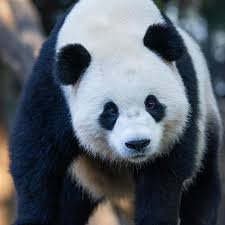

----------------------------------------
Match #2
File: elephant-2870777_1280.json
Context: Subject: African elephant
Description: A large African elephant walks directly towards the viewer on...


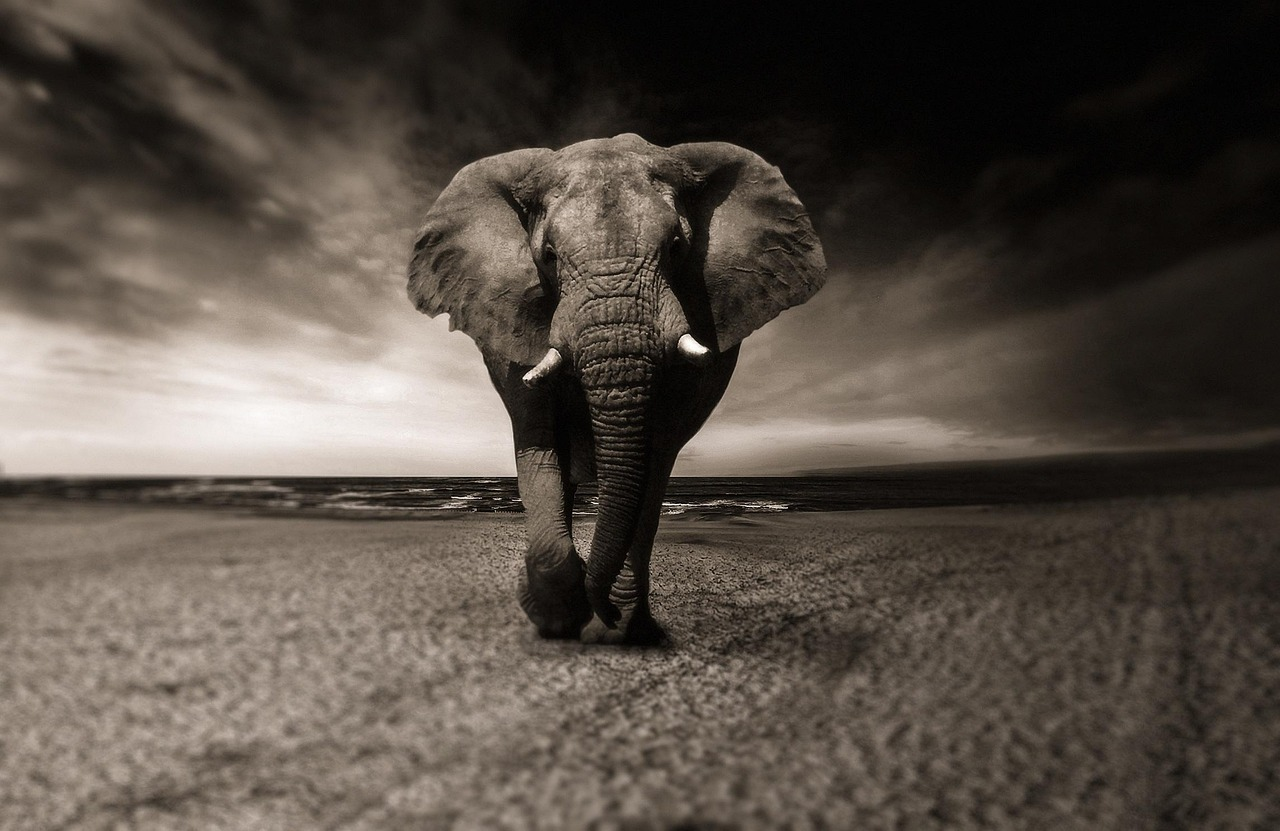

----------------------------------------
Match #3
File: kangaroo.json
Context: Subject: Kangaroo
Description: A brown kangaroo is captured mid-stride, hopping across a grassy fiel...


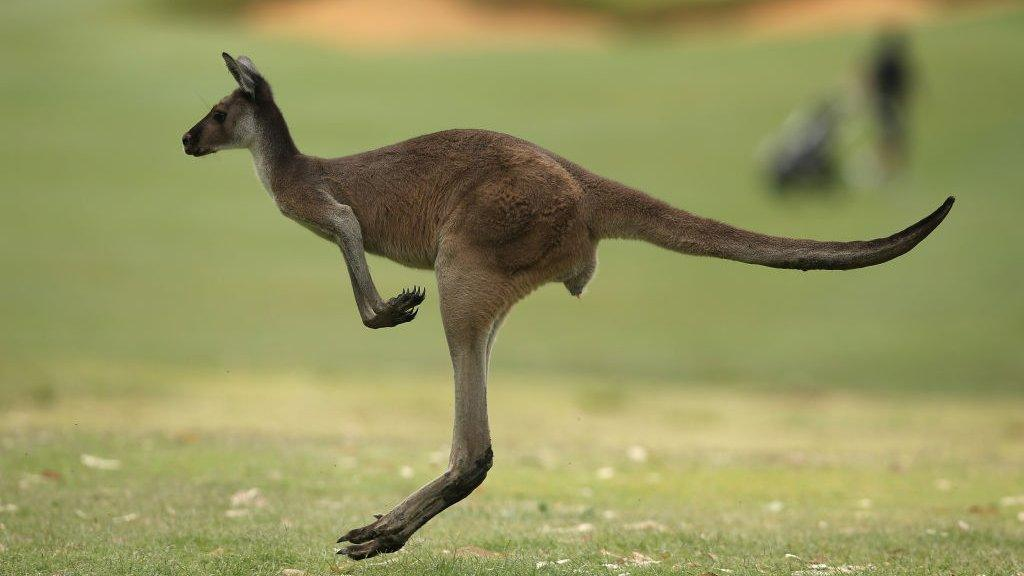

----------------------------------------


In [35]:
import os, shutil, requests
from langchain_chroma import Chroma
from langchain_core.embeddings import Embeddings
from google.colab import userdata
from IPython.display import display, Image

API_KEY = userdata.get("NEW_1")

db_path_local = "/content/chroma_db"
db_path_drive = "/content/drive/MyDrive/21 day assignments/GenAI/chroma_db"

class GeminiEmbeddings(Embeddings):
    def __init__(self, api_key, model="gemini-embedding-001"):
        self.api_key = api_key
        self.url = (
            f"https://generativelanguage.googleapis.com/v1beta/models/"
            f"{model}:embedContent?key={api_key}"
        )
        self.model_path = f"models/{model}"

    def _embed(self, text, task_type):
        body = {
            "model": self.model_path,
            "content": {"parts": [{"text": text}]},
            "taskType": task_type
        }
        r = requests.post(self.url, json=body)
        r.raise_for_status()
        return r.json()["embedding"]["values"]

    def embed_documents(self, texts):
        return [self._embed(t, "RETRIEVAL_DOCUMENT") for t in texts]

    def embed_query(self, text):
        return self._embed(text, "RETRIEVAL_QUERY")

embeddings = GeminiEmbeddings(API_KEY)

# Copy DB from Drive to local (writable) if not already there
if not os.path.exists(db_path_local):
    shutil.copytree(db_path_drive, db_path_local)
    print("Copied DB from Drive to local.")

vectorstore = Chroma(persist_directory=db_path_local, embedding_function=embeddings)
print(f"Database loaded with {vectorstore._collection.count()} documents.")

def search_images(query, top_k=3):
    results = vectorstore.similarity_search(query, k=top_k)
    if not results:
        print("No matches found.")
        return
    for i, doc in enumerate(results):
        file_path = doc.metadata.get("file_path", "")
        file_name = doc.metadata.get("file_name", "")
        print(f"Match #{i+1}")
        print(f"File: {file_name}")
        print(f"Context: {doc.page_content[:100]}...")
        if file_path and os.path.exists(file_path):
            display(Image(filename=file_path, width=300))
        else:
            print(f"Image file not found at: {file_path}")
        print("-" * 40)

search_images("man")

Match #1
File: tiger.json
Context: Subject: Tiger
Description: A tiger is captured in a close-up, head-on portrait, resting on a dark, ...


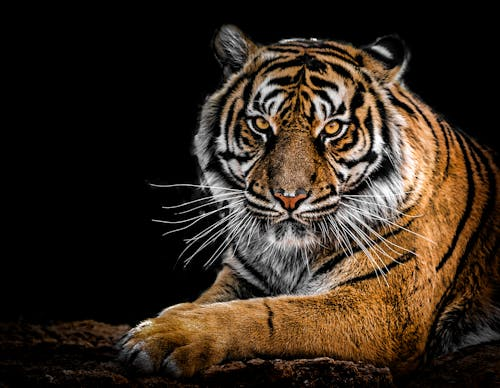

----------------------------------------
Match #2
File: Golden-Retriever.json
Context: Subject: Golden Retriever puppy
Description: A golden retriever puppy with light golden fur sits in ...


ValueError: Cannot embed the 'webp' image format

In [39]:
search_images("cat")